# Tutorial 16: Fault Detection, Isolation, and Recovery (FDIR)

This tutorial covers **FDIR** techniques for spacecraft systems. FDIR is critical for autonomy and survival, ensuring the spacecraft can detect failures in sensors or actuators and respond appropriately (e.g., by re-allocating controls or triggering a **Safe Mode**).

---
## 1. Theory Prerequisite

### 1.1 Residual Generation
A **residual** is a signal that is zero (or small) in normal operation and non-zero during a fault.
- **Analytical Redundancy**: Comparing outputs of two different sensors/models that relate algebraically.
- **Observer Residuals**: Using an estimator (like a Luenberger Observer) to predict the output $\hat{y}$. Residual $r = y - \hat{y}$.

### 1.2 Parity Space
For redundant sensors (e.g., 4 gyros for 3 axes):
$$ y = M x + v + f $$
where $M$ is the geometry matrix ($p \times n$, $p > n$).
We find a Parity Matrix $P$ such that $P M = 0$ and $P P^T = I$.
- **Parity Vector**: $p_{vec} = P y$
- **Detection**: $\|p_{vec}\| > \text{threshold}$
- **Isolation**: The column of $P$ that aligns best with $p_{vec}$ identifies the faulty sensor.

### 1.3 Actuator Accommodation
Control allocation: $\tau = B u$. We find $u$ to minimize $u^T W u$:
$$ u = W^{-1} B^T (B W^{-1} B^T)^{-1} \tau $$
If actuator $i$ fails, we set its weight $W_{ii} \to \infty$ (or very large), forcing the allocator to use the remaining healthy actuators.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from gnc_toolkit.fdir.parity_space import ParitySpaceDetector
from gnc_toolkit.fdir.failure_accommodation import ActuatorAccommodation
from gnc_toolkit.fdir.safe_mode import SafeModeLogic, SafeModeCondition, SystemMode

print("Imports successful.")

Imports successful.


## 2. Demonstration: Sensor Fault Isolation (Parity Space)

We simulate 4 gyros aligned on a tetrahedral structure tracking a 3D rate vector.
Around step 100, **Gyro 2 develops a bias fault (sticks/off-by-one).**

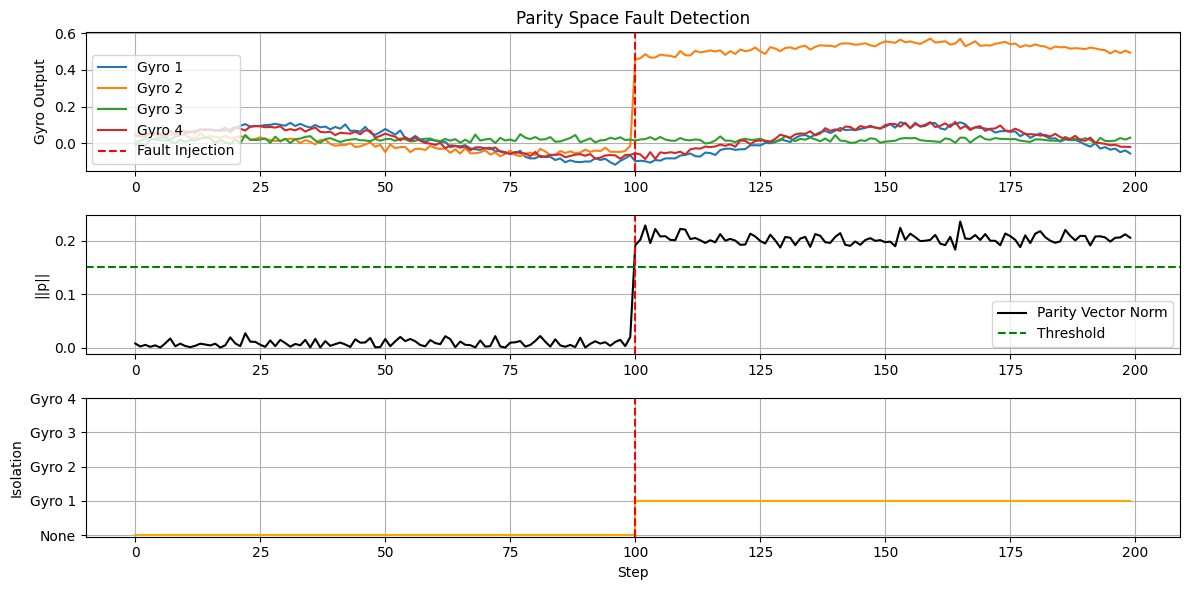

In [6]:
# Geometry Matrix for 4 Gyros (Rows = Gyro axes in Body Frame)
M = np.array([
    [1.0, 0.0, 0.0],       # Gyro 1 on X
    [0.0, 1.0, 0.0],       # Gyro 2 on Y
    [0.0, 0.0, 1.0],       # Gyro 3 on Z
    [0.577, 0.577, 0.577]  # Gyro 4 skewed
])

detector = ParitySpaceDetector(M)

steps = 200
dt = 0.1
threshold = 0.15

history_pvec_norm = []
history_isolated = []
history_y = []

for k in range(steps):
    # 1. True Rate (sine wave for dynamics)
    true_rate = np.array([0.1*np.sin(0.05*k), 0.05*np.cos(0.04*k), 0.02])
    
    # 2. Measurement without fault
    noise = np.random.normal(0, 0.01, size=4)
    y = M @ true_rate + noise
    
    # 3. Inject Fault at k >= 100 on Gyro 2 (index 1)
    if k >= 100:
        y[1] += 0.5 # Add step bias
        
    # 4. Parity Space detection
    p_vec = detector.get_parity_vector(y)
    p_norm = np.linalg.norm(p_vec)
    
    isolated_idx = -1
    if detector.detect_fault(y, threshold):
         isolated_idx = detector.isolate_fault(y)
            
    history_pvec_norm.append(p_norm)
    history_isolated.append(isolated_idx)
    history_y.append(y.copy())

history_y = np.array(history_y)
history_pvec_norm = np.array(history_pvec_norm)
history_isolated = np.array(history_isolated)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
for i in range(4):
    plt.plot(history_y[:, i], label=f'Gyro {i+1}')
plt.axvline(100, color='r', linestyle='--', label='Fault Injection')
plt.ylabel('Gyro Output')
plt.legend(loc='lower left')
plt.title('Parity Space Fault Detection')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(history_pvec_norm, label='Parity Vector Norm', color='k')
plt.axhline(threshold, color='g', linestyle='--', label='Threshold')
plt.axvline(100, color='r', linestyle='--')
plt.ylabel('||p||')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.step(range(steps), history_isolated + 1, where='post', color='orange', label='Isolated Index')
plt.axvline(100, color='r', linestyle='--')
plt.yticks(range(0, 5), ['None', 'Gyro 1', 'Gyro 2', 'Gyro 3', 'Gyro 4'])
plt.xlabel('Step')
plt.ylabel('Isolation')
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Demonstration: Actuator Failure Accommodation

We have 4 Reaction Wheels generating moments along 3 axes. 
At Step 50, **Reaction Wheel 1 completely fails (health sets to 0)**. We show that the accommodation weights update to rely only on the remaining healthy wheels.

Nominal commands: [ 0.08834041 -0.06165959  0.00834041  0.02020726]
Allocated after failure: [ 5.30364342e-13 -1.50000000e-01 -8.00000000e-02  1.73310225e-01]

Demand 		: [ 0.1  -0.05  0.02]
Actual Nominal 	: [ 0.1  -0.05  0.02]
Actual Corrected: [ 0.1  -0.05  0.02]


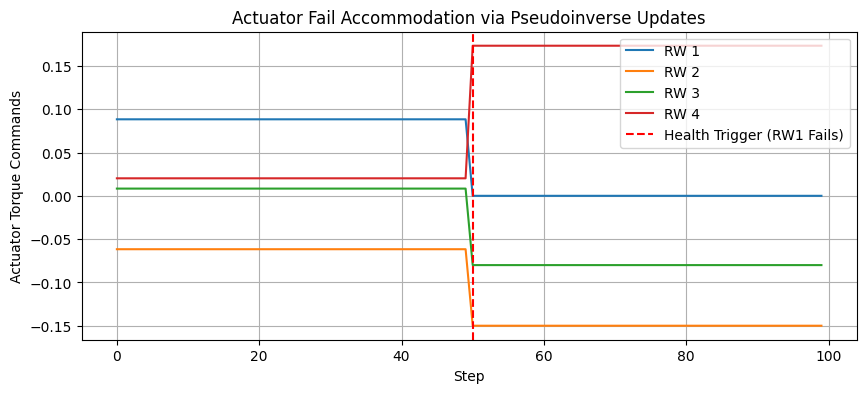

In [7]:
# Control Allocation Matrix for 4 Wheels (Columns = Wheel normal vectors)
B = np.array([
    [1.0, 0.0, 0.0, 0.577],
    [0.0, 1.0, 0.0, 0.577],
    [0.0, 0.0, 1.0, 0.577]
])

accommodation = ActuatorAccommodation(B)

tau_demand = np.array([0.1, -0.05, 0.02]) # Constant demand for demo

u_nominal = accommodation.allocate(tau_demand)

# 1. Normal Operation
print("Nominal commands:", u_nominal.flatten())

# 2. RW 1 FAILS (index 0)
accommodation.set_health(0, 0.0)
u_failed = accommodation.allocate(tau_demand)
print("Allocated after failure:", u_failed.flatten())

# 3. Verify Torque matches demand
tau_actual_nom = B @ u_nominal
tau_actual_fail = B @ u_failed

print(f"\nDemand \t\t: {tau_demand}")
print(f"Actual Nominal \t: {tau_actual_nom.flatten()}")
print(f"Actual Corrected: {tau_actual_fail.flatten()}")

# Simulating over time index
accommodation.set_health(0, 1.0) # Reset health
history_u = []
for k in range(100):
    if k == 50:
         accommodation.set_health(0, 0.0) # Fail
    u = accommodation.allocate(tau_demand)
    history_u.append(u.flatten())
    
history_u = np.array(history_u)

plt.figure(figsize=(10, 4))
plt.plot(history_u[:, 0], label='RW 1')
plt.plot(history_u[:, 1], label='RW 2')
plt.plot(history_u[:, 2], label='RW 3')
plt.plot(history_u[:, 3], label='RW 4')
plt.axvline(50, color='r', linestyle='--', label='Health Trigger (RW1 Fails)')
plt.xlabel('Step')
plt.ylabel('Actuator Torque Commands')
plt.title('Actuator Fail Accommodation via Pseudoinverse Updates')
plt.legend()
plt.grid(True)
plt.show()

## 4. Demonstration: Safe Mode Transition Logic

We tie the Residual Detector to a `SafeModeLogic` unit. If the residual condition is high for more than a trigger time duration, mode transitions to **SAFE**.

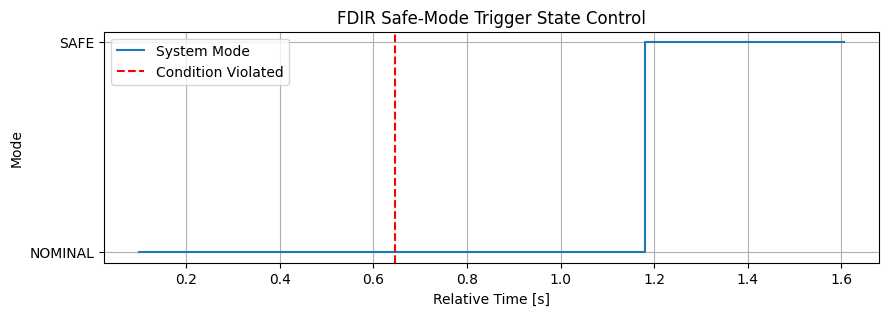

Logs:
Time 1.18s: NOMINAL -> SAFE Reason: Condition HI_RESIDUAL triggered


In [8]:
safe_logic = SafeModeLogic()

# Condition stateful simulator for mockup time check
residual_val = 0.0
def check_hi_residual():
    return residual_val > 1.0

condition = SafeModeCondition(check_hi_residual, trigger_time_sec=0.5)
safe_logic.add_condition("HI_RESIDUAL", condition)

history_mode = []
time_elapsed = []
start_sim = time.time()

# Run mock loop
for k in range(15):
    time.sleep(0.1)
    curr_time = time.time() - start_sim
    
    # Fault occurs at k == 5
    if k >= 5:
        residual_val = 1.5 # Fault trigger HIGH
    else:
        residual_val = 0.1 # Normal
        
    mode_status = safe_logic.update()
    history_mode.append(mode_status.value)
    time_elapsed.append(curr_time)
    
plt.figure(figsize=(10, 3))
plt.step(time_elapsed, history_mode, label='System Mode', where='post')
plt.xlabel('Relative Time [s]')
plt.ylabel('Mode')
plt.title('FDIR Safe-Mode Trigger State Control')
plt.axvline(time_elapsed[5], color='r', linestyle='--', label='Condition Violated')
plt.legend()
plt.grid(True)
plt.show()

print("Logs:")
for entry in safe_logic.history:
    print(f"Time {entry['time']-start_sim:.2f}s: {entry['from_mode']} -> {entry['to_mode']} Reason: {entry['reason']}")